<a href="https://colab.research.google.com/github/aseel1/Deep-learning/blob/main/HW-3/HW3_PT2_322512690_212393532_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Assignment 3 - Part 2
### Latent Space Visualization

Student 1: Rajaa Haj 322512690

Student 2: Aseel Shaheen 212393532

# Imports

In [1]:
import torch
import numpy as np
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from mpl_toolkits.axes_grid1 import ImageGrid
from torchvision.utils import save_image, make_grid
import torch.nn.functional as F
import random
from sklearn.manifold import TSNE

# Preprocessing

In [2]:
# create a transofrm to apply to each datapoint
transform = transforms.Compose([transforms.ToTensor()])

# download the MNIST datasets
path = '~/datasets'
train_dataset = MNIST(path, transform=transform, download=True)
test_dataset  = MNIST(path, transform=transform, download=True)

# create train and test dataloaders
batch_size = 100
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]


Extracting /root/datasets/MNIST/raw/train-images-idx3-ubyte.gz to /root/datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 473kB/s]


Extracting /root/datasets/MNIST/raw/train-labels-idx1-ubyte.gz to /root/datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]


Extracting /root/datasets/MNIST/raw/t10k-images-idx3-ubyte.gz to /root/datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 8.95MB/s]


Extracting /root/datasets/MNIST/raw/t10k-labels-idx1-ubyte.gz to /root/datasets/MNIST/raw



# Encoder Class

In [3]:
class Encoder(nn.Module):

    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc1=nn.Linear(input_dim,hidden_dim)
        self.fc2=nn.Linear(hidden_dim,hidden_dim)
        # get the mean of the latent space
        self.mu=nn.Linear(hidden_dim,latent_dim)
        # get the log var of the latent space
        self.log_var=nn.Linear(hidden_dim,latent_dim)

    def forward(self, x):

      #x=x.view(x.size(0),-1)  #flattern the input
      x=F.relu(self.fc1(x))
      x=F.relu(self.fc2(x))
      mu=self.mu(x)
      log_var=self.log_var(x)

      return mu,log_var


# Decoder Class

In [4]:
class Decoder(nn.Module):

    def __init__(self, output_dim, hidden_dim, latent_dim):
        super(Decoder, self).__init__()
        self.fc1=nn.Linear(latent_dim,hidden_dim)
        self.fc2=nn.Linear(hidden_dim,hidden_dim)
        self.fc3=nn.Linear(hidden_dim,output_dim)



    def forward(self, x):
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=torch.sigmoid(self.fc3(x))
        #x=x.view(x.size(0),1,28,28)  # reshape to image format
        return x

# Variational Auto Encoder Class

In [33]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=2, device=device):
        super(VAE, self).__init__()

        self.device= device
        self.encoder=Encoder(input_dim,hidden_dim,latent_dim)
        self.decoder=Decoder(input_dim,hidden_dim,latent_dim)


    def reparameterize(self,mu,log_var):

        std=torch.exp(0.5*log_var)
        epslion=torch.randn_like(std)
        z=mu+epslion*std
        return z




    def forward(self, x):
        # write your code here

        x=x.view(x.size(0),-1)
        mu,logvar=self.encoder(x)
        z=self.reparameterize(mu,logvar)
        recon_x=self.decoder(z)
        return recon_x,mu,logvar

In [34]:
model = VAE().to(device)
lr=0.001
optimizer = Adam(model.parameters(), lr)

# Loss Function Class


i add the 1e-10 to avoid log(0)

In [35]:
def loss_function(x, x_hat, mean, log_var):
    # write your code heres

    #x_hat=x_hat.view(x.size(0),-1)

    bce_loss=-torch.sum(x*torch.log(x_hat+ 1e-10)+(1-x)*torch.log(1-x_hat+ 1e-10))


    kld=-0.5*torch.sum(1+log_var-mean.pow(2)-log_var.exp())

    return bce_loss+kld



    #return torch.mean(bce_loss + kld)

# Training Loop

In [36]:
def train(model, optimizer, epochs, device, x_dim=784): # Modify, add the evaluation step after each 10 epochs
    model.train()
    for epoch in range(epochs):
        overall_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            x = x.view(batch_size, x_dim).to(device)

            optimizer.zero_grad()

            x_hat, mean, log_var = model(x)
            loss = loss_function(x, x_hat, mean, log_var)

            overall_loss += loss.item()

            loss.backward()
            optimizer.step()

        print("\tEpoch", epoch + 1, "\tAverage Loss: ", overall_loss/(batch_idx*batch_size))

        # After 10 epochs , generate and plot a digit
        if (epoch+1) % 10 ==0:

          with torch.no_grad():

            z=torch.randn(1,model.decoder.fc1.in_features,device=device)

            generated_digit=model.decoder(z).squeeze().cpu().detach().numpy()

            generated_digit=generated_digit.reshape(28,28)

            # plot the generated digit
            plt.imshow(generated_digit,cmap='gray')
            plt.axis('off')
            plt.title(f"Generated Image at Epoch {epoch+1}")
            plt.show()


    return overall_loss

	Epoch 1 	Average Loss:  177.3631155930457
	Epoch 2 	Average Loss:  157.59657182543822
	Epoch 3 	Average Loss:  152.1834913495148
	Epoch 4 	Average Loss:  149.04257638055614
	Epoch 5 	Average Loss:  147.25014914179883
	Epoch 6 	Average Loss:  145.85387445873332
	Epoch 7 	Average Loss:  144.85173389568553
	Epoch 8 	Average Loss:  144.0395958107262
	Epoch 9 	Average Loss:  143.49911991991863
	Epoch 10 	Average Loss:  142.90683513864252


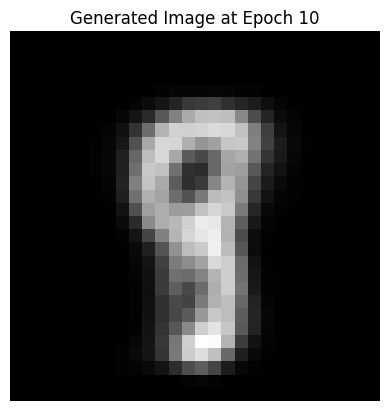

	Epoch 11 	Average Loss:  142.13187684226315
	Epoch 12 	Average Loss:  141.8044452505478
	Epoch 13 	Average Loss:  141.28733129434474
	Epoch 14 	Average Loss:  140.87678898424457
	Epoch 15 	Average Loss:  140.50402505151814
	Epoch 16 	Average Loss:  140.24100305522225
	Epoch 17 	Average Loss:  139.79518619900355
	Epoch 18 	Average Loss:  139.45957287210456
	Epoch 19 	Average Loss:  139.34630688191257
	Epoch 20 	Average Loss:  139.31749382108202


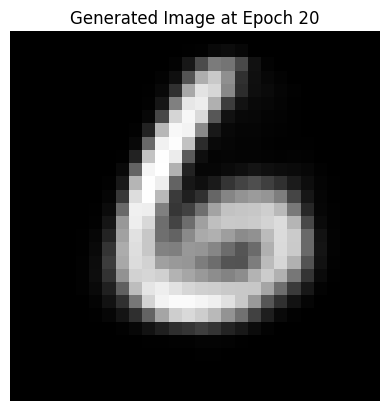

	Epoch 21 	Average Loss:  139.11182124830447
	Epoch 22 	Average Loss:  138.94503412262625
	Epoch 23 	Average Loss:  138.9760169292571
	Epoch 24 	Average Loss:  138.46026096554152
	Epoch 25 	Average Loss:  138.07275731362165
	Epoch 26 	Average Loss:  137.95609381521285
	Epoch 27 	Average Loss:  137.9746266564065
	Epoch 28 	Average Loss:  137.544125136947
	Epoch 29 	Average Loss:  137.5467070605958
	Epoch 30 	Average Loss:  137.28777029097975


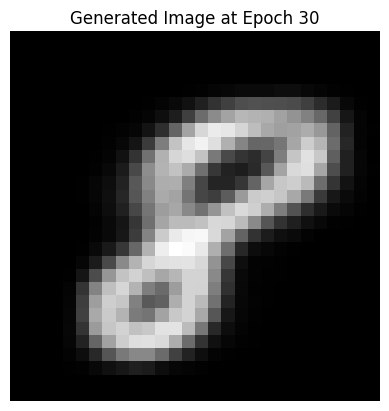

	Epoch 31 	Average Loss:  137.17676188830342
	Epoch 32 	Average Loss:  136.8431430965672
	Epoch 33 	Average Loss:  137.40610747730594
	Epoch 34 	Average Loss:  136.80293840971933
	Epoch 35 	Average Loss:  136.8699593723915
	Epoch 36 	Average Loss:  136.58249805991758
	Epoch 37 	Average Loss:  136.4180827257669
	Epoch 38 	Average Loss:  136.54855220941153
	Epoch 39 	Average Loss:  136.31840554570118
	Epoch 40 	Average Loss:  136.30024748278382


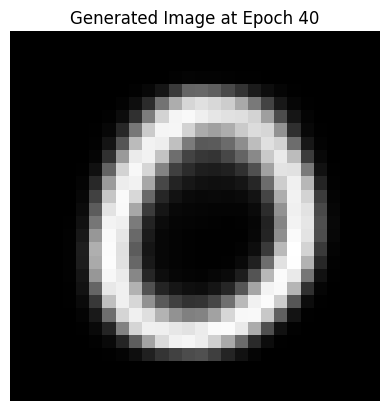

	Epoch 41 	Average Loss:  136.07686006625627
	Epoch 42 	Average Loss:  135.87838301465985
	Epoch 43 	Average Loss:  136.03964912223498
	Epoch 44 	Average Loss:  136.13284520424665
	Epoch 45 	Average Loss:  135.78130450164338
	Epoch 46 	Average Loss:  135.9405727318969
	Epoch 47 	Average Loss:  135.8718975147381
	Epoch 48 	Average Loss:  135.7362972793197
	Epoch 49 	Average Loss:  135.2889591376252
	Epoch 50 	Average Loss:  135.33263616444074


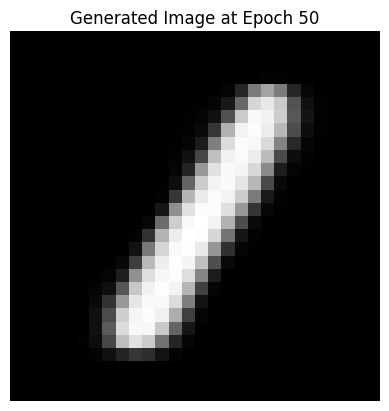

8106424.90625

In [37]:
train(model, optimizer, epochs=50, device=device)

# Generate and plot digit

In [38]:
import torch
import matplotlib.pyplot as plt

def generate_digit(mean, var):
    """
    Generates and directly plots a handwritten digit using the provided mean and variance.

    Args:
        mean (float or list): Mean of the latent vector.
        var (float or list): Variance of the latent vector.

    Returns:
        None (Plots the generated digit directly)
    """
    model.eval()  # Set model to evaluation mode

    # Ensure `mean` and `var` are tensors of shape `(latent_dim,)`
    if isinstance(mean, float):  # If scalar, expand to (latent_dim,)
        mean = torch.full((model.decoder.fc1.in_features,), mean, dtype=torch.float32).to(device)
    elif isinstance(mean, list):  # Convert list to tensor
        mean = torch.tensor(mean, dtype=torch.float32).to(device)

    if isinstance(var, float):  # If scalar, expand to (latent_dim,)
        var = torch.full((model.decoder.fc1.in_features,), var, dtype=torch.float32).to(device)
    elif isinstance(var, list):  # Convert list to tensor
        var = torch.tensor(var, dtype=torch.float32).to(device)

    with torch.no_grad():
        # Convert variance to standard deviation
        std = torch.sqrt(var)
        # Sample from N(0,1) (random noise)
        eps = torch.randn_like(std).to(device)
        # Apply reparameterization trick: z = mean + eps * std
        z = mean + eps * std

        # Pass latent vector `z` to the decoder
        digit = model.decoder(z.unsqueeze(0)).cpu().view(28, 28)

    # Plot the generated digit directly
    plt.imshow(digit, cmap="gray")
    plt.title(f"Generated digit (mu={mean[0].item()}, var={var[0].item()})")
    plt.axis('off')
    plt.show()


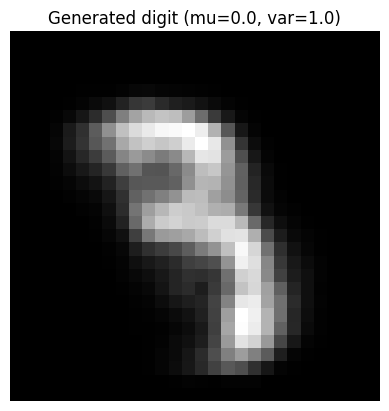

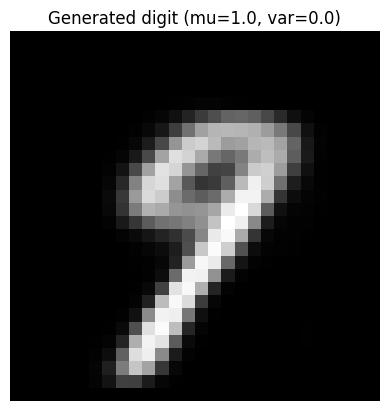

(None, None)

In [39]:
generate_digit(0.0, 1.0), generate_digit(1.0, 0.0)

# Latent Space Grid Visualization

In [40]:
def plot_latent_space(model, scale=2.0, digit_size=28, figsize=15):
    """
    Plots the latent space by generating a grid of images from linearly interpolated 2D latent codes.

    Args:
        model: Trained VAE model (latent_dim must be 2).
        scale: Range for sampling latent codes (e.g., [-scale, scale]).
        digit_size: Size of MNIST digits (default 28x28).
        figsize: Figure size for the plot.
    """
    model.eval()
    grid_size = 15  # Number of points per axis

    # Generate a 2D grid of latent codes
    grid_x = np.linspace(-scale, scale, grid_size)
    grid_y = np.linspace(-scale, scale, grid_size)

    figure = np.zeros((digit_size * grid_size, digit_size * grid_size))

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            # Create latent vector (z1, z2) = (xi, yi)
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)

            with torch.no_grad():
                generated_image = model.decoder(z).squeeze().cpu().numpy().reshape(digit_size, digit_size)

            # Assign the generated image to the grid
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = generated_image

    # Plot the grid of images
    plt.figure(figsize=(figsize, figsize))
    plt.imshow(figure, cmap="gray", extent=[-scale, scale, -scale, scale])
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title(f"VAE Latent Space (Scale={scale})")
    plt.axis("on")  # Show axes to visualize latent dimensions
    plt.show()

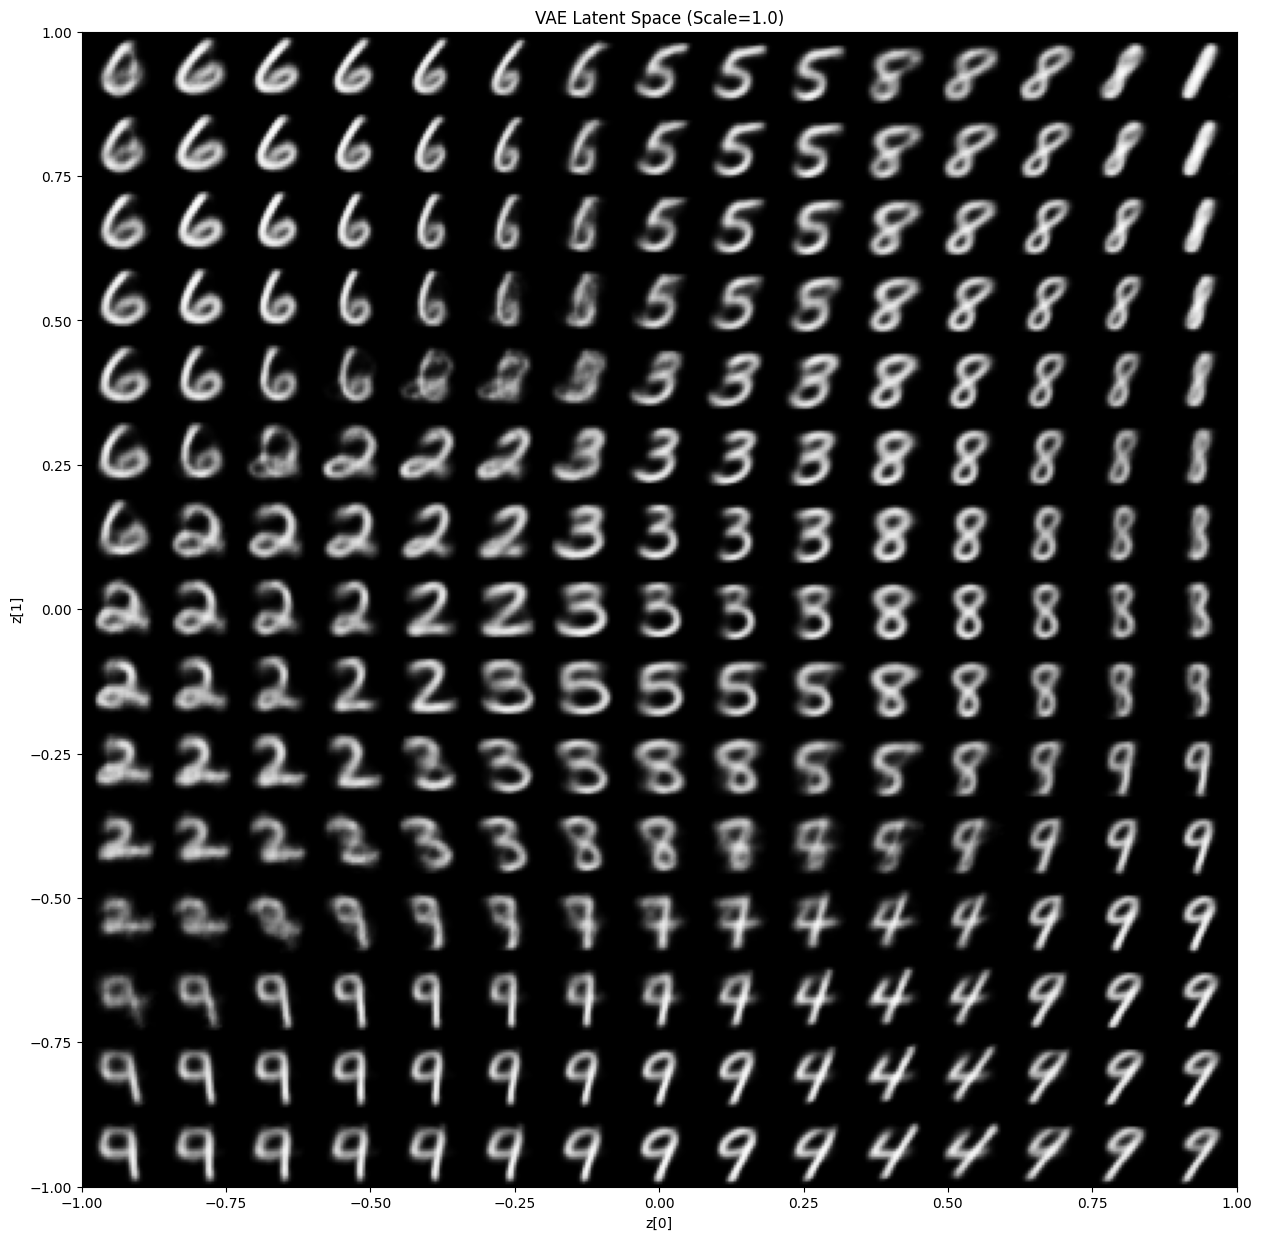

In [41]:
plot_latent_space(model, scale=1.0)

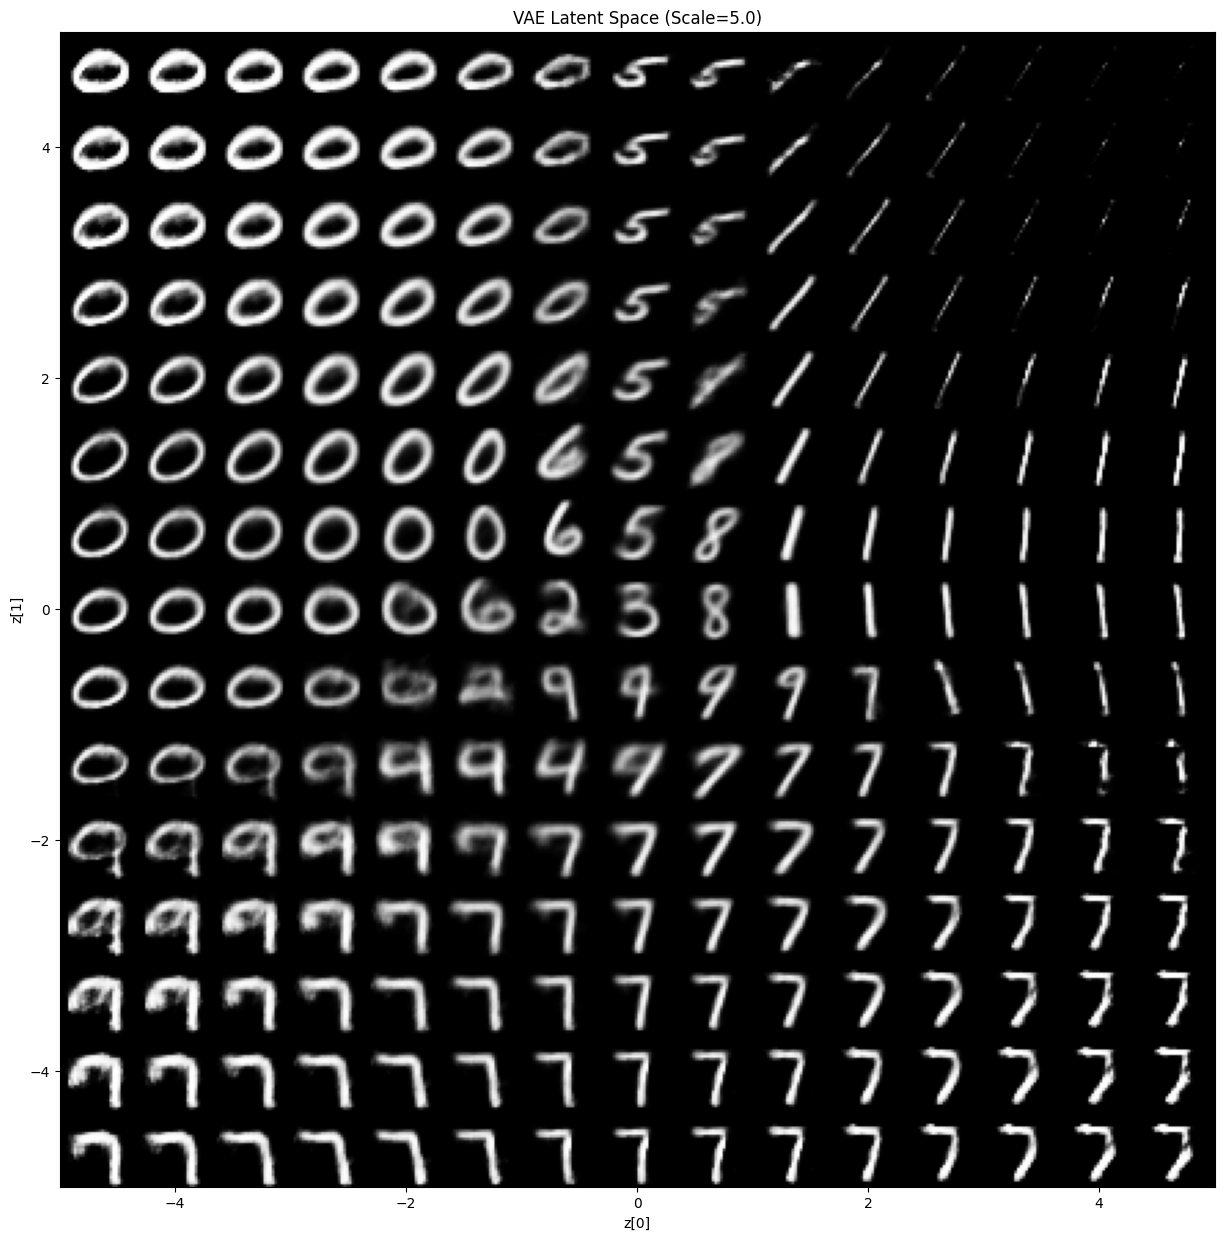

In [42]:
plot_latent_space(model, scale=5.0)

# Linear Interpolation

In [48]:
def linear_interpolation(model, dataset, num_steps=10):
    model.eval()
    device = next(model.parameters()).device

    # Step 1: Randomly select two different classes (e.g., "3" and "7")
    labels = dataset.targets.numpy()
    unique_labels = np.unique(labels)
    label1, label2 = np.random.choice(unique_labels, 2, replace=False)

    # Step 2: Randomly pick one image from each class (not just the first occurrence)
    idx1 = np.random.choice(np.where(labels == label1)[0])  # Random index for label1
    idx2 = np.random.choice(np.where(labels == label2)[0])  # Random index for label2

    img1, _ = dataset[idx1]
    img2, _ = dataset[idx2]

    # Step 3: Encode to latent codes (μ)
    img1 = img1.view(1, -1).to(device)
    img2 = img2.view(1, -1).to(device)
    with torch.no_grad():
        mu1, _ = model.encoder(img1)
        mu2, _ = model.encoder(img2)

    # Step 4: Linear interpolation between μ1 and μ2
    interpolated_zs = [mu1 + (mu2 - mu1) * t for t in torch.linspace(0, 1, num_steps)]

    # Step 5: Decode and plot
    fig, axes = plt.subplots(1, num_steps, figsize=(20, 2))
    for i, z in enumerate(interpolated_zs):
        with torch.no_grad():
            generated = model.decoder(z).squeeze().cpu().numpy().reshape(28, 28)
        axes[i].imshow(generated, cmap="gray")
        axes[i].axis("off")
    plt.suptitle(f"Interpolation: Class {label1} → Class {label2}")
    plt.show()

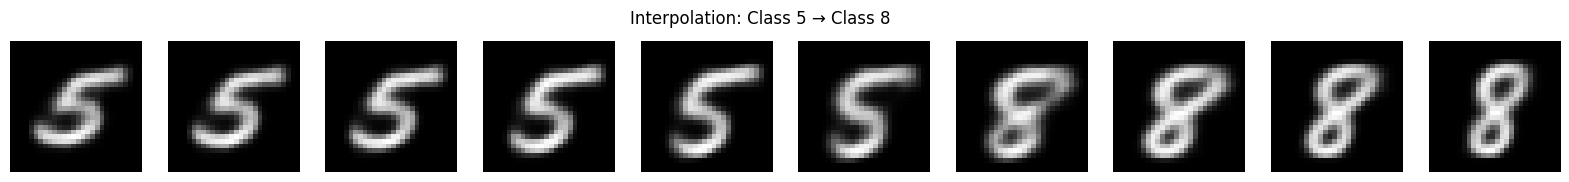

In [60]:
# Example usage after training the VAE
linear_interpolation(model, train_dataset, num_steps=10)

## BONUS Question
In this task, we visualized the learned latent space of a trained Variational Autoencoder (VAE) by generating a video of smooth transitions between digits.
Since we're smoothly traversing the latent space of the trained VAE with latent_dim=200 the vedio is NOT just show one number changing shape, Instead, it should smoothly transition between different numbers,
Some areas might linger on one digit type if that region is dominated by a specific class
The transition should gradually morph from one digit to another without sudden jumps.

In [61]:
import os
import imageio
import numpy as np
import matplotlib.pyplot as plt
import torch

def generate_interpolation_video(model, dataset, output_path="interpolation.mp4", num_steps=30, fps=10, resize_factor=10):
    """
    Generates a video of linear interpolation between two random digits.

    Args:
        model (nn.Module): Trained VAE model.
        dataset (Dataset): MNIST dataset.
        output_path (str): Path to save the video (e.g., "interpolation.mp4").
        num_steps (int): Number of interpolation frames.
        fps (int): Frames per second for the video.
        resize_factor (int): Upscale images for better visibility (e.g., 10x).
    """
    # Create temporary directory for frames
    os.makedirs("temp_frames", exist_ok=True)

    # Generate interpolation frames
    model.eval()
    device = next(model.parameters()).device
    labels = dataset.targets.numpy()
    unique_labels = np.unique(labels)
    label1, label2 = np.random.choice(unique_labels, 2, replace=False)

    # Randomly select images from the two classes
    idx1 = np.random.choice(np.where(labels == label1)[0])
    idx2 = np.random.choice(np.where(labels == label2)[0])
    img1, _ = dataset[idx1]
    img2, _ = dataset[idx2]

    # Encode to latent vectors
    img1 = img1.view(1, -1).to(device)
    img2 = img2.view(1, -1).to(device)
    with torch.no_grad():
        mu1, _ = model.encoder(img1)
        mu2, _ = model.encoder(img2)

    # Generate and save frames
    frames = []
    for t in np.linspace(0, 1, num_steps):
        z = mu1 + (mu2 - mu1) * t
        with torch.no_grad():
            generated = model.decoder(z).squeeze().cpu().numpy().reshape(28, 28)

        # Resize for better visibility
        generated = generated.repeat(resize_factor, axis=0).repeat(resize_factor, axis=1)
        frames.append((generated * 255).astype(np.uint8))  # Scale to 0-255

    # Save frames as video
    imageio.mimsave(output_path, frames, fps=fps, codec="libx264")
    print(f"Video saved to {output_path}")

    # Cleanup (optional)
    # import shutil
    # shutil.rmtree("temp_frames")

In [62]:
# After training the VAE
generate_interpolation_video(
    model,
    train_dataset,
    output_path="digit_interpolation.mp4",
    num_steps=60,  # More steps = smoother video
    fps=20,         # Higher FPS = faster playback
    resize_factor=10 # 28x28 → 280x280 pixels
)

Video saved to digit_interpolation.mp4
